# Lab 3: Contextual Bandit-Based News Article Recommendation System
## Part 1: Data Preprocessing and User Classification

**Student Roll Number:** U20230090  
**Name:** Lakshit Tyagi

## Import Required Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

## 1. Data Pre-processing (10 Points)

### 1.1 Load Datasets

DATASET OVERVIEW
Train (with labels): (2000, 33)
Test (unlabeled): (2000, 32)
News Articles: (209527, 6)

Target column: 'label'
Distribution:
label
user_2    712
user_1    707
user_3    581
Name: count, dtype: int64


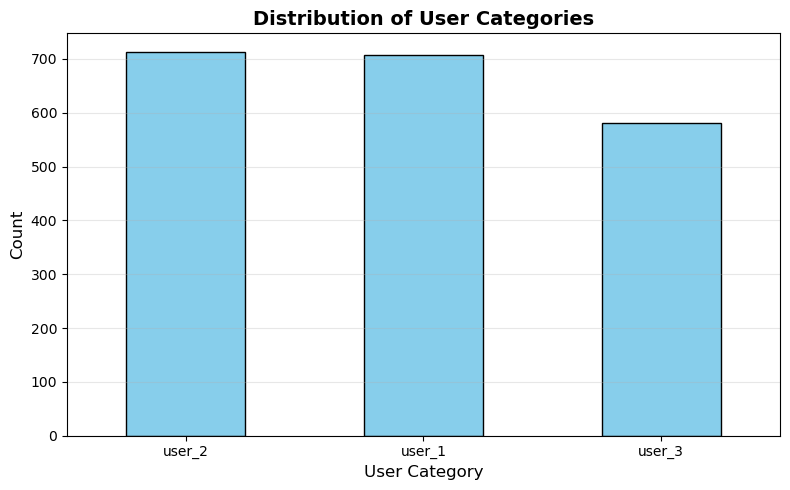

In [28]:
# Load datasets
train_users_full = pd.read_csv('data/train_users.csv')
test_users_final = pd.read_csv('data/test_users.csv')  # For final predictions (unlabeled)
news_articles = pd.read_csv('data/news_articles.csv')

# Clean column names
train_users_full.columns = train_users_full.columns.str.strip()
test_users_final.columns = test_users_final.columns.str.strip()
news_articles.columns = news_articles.columns.str.strip()

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Train (with labels): {train_users_full.shape}")
print(f"Test (unlabeled): {test_users_final.shape}")
print(f"News Articles: {news_articles.shape}")

print(f"\nTarget column: 'label'")
print(f"Distribution:\n{train_users_full['label'].value_counts()}")

# Visualize
plt.figure(figsize=(8, 5))
train_users_full['label'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of User Categories', fontsize=14, fontweight='bold')
plt.xlabel('User Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 1.2 Split into Train/Validation

In [30]:
# Separate features and target
TARGET_COLUMN = 'label'

X_full = train_users_full.drop([TARGET_COLUMN, 'user_id'], axis=1)
y_full = train_users_full[TARGET_COLUMN]

# Split into train (80%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full  # Ensures balanced split
)

print("="*60)
print("TRAIN-VALIDATION SPLIT (80-20)")
print("="*60)
print(f"Training set: X={X_train.shape}, y={y_train.shape}")
print(f"Validation set: X={X_val.shape}, y={y_val.shape}")

print(f"\nTraining set distribution:\n{y_train.value_counts()}")
print(f"\nValidation set distribution:\n{y_val.value_counts()}")

print(f"\nFeatures ({len(X_train.columns)}):")
print(X_train.columns.tolist())

TRAIN-VALIDATION SPLIT (80-20)
Training set: X=(1600, 31), y=(1600,)
Validation set: X=(400, 31), y=(400,)

Training set distribution:
label
user_2    570
user_1    565
user_3    465
Name: count, dtype: int64

Validation set distribution:
label
user_2    142
user_1    142
user_3    116
Name: count, dtype: int64

Features (31):
['age', 'income', 'clicks', 'purchase_amount', 'session_duration', 'content_variety', 'engagement_score', 'num_transactions', 'avg_monthly_spend', 'avg_cart_value', 'browsing_depth', 'revisit_rate', 'scroll_activity', 'time_on_site', 'interaction_count', 'preferred_price_range', 'discount_usage_rate', 'wishlist_size', 'product_views', 'repeat_purchase_gap (days)', 'churn_risk_score', 'loyalty_index', 'screen_brightness', 'battery_percentage', 'cart_abandonment_count', 'browser_version', 'background_app_count', 'session_inactivity_duration', 'network_jitter', 'region_code', 'subscriber']


### 1.3 Handle Missing Values

In [31]:
# Identify column types
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object', 'bool']).columns

print("="*60)
print("HANDLING MISSING VALUES")
print("="*60)
print(f"Numerical columns: {len(numerical_cols)}")
print(f"Categorical/Boolean columns: {len(categorical_cols)}")
if len(categorical_cols) > 0:
    print(f"Categorical columns: {list(categorical_cols)}")

print(f"\nMissing values before:")
print(f"X_train: {X_train.isnull().sum().sum()}")
print(f"X_val: {X_val.isnull().sum().sum()}")

# Fill numerical with median
for col in numerical_cols:
    if X_train[col].isnull().sum() > 0:
        median_val = X_train[col].median()
        X_train[col].fillna(median_val, inplace=True)
        X_val[col].fillna(median_val, inplace=True)

# Fill categorical with mode
for col in categorical_cols:
    if X_train[col].isnull().sum() > 0:
        mode_val = X_train[col].mode()[0]
        X_train[col].fillna(mode_val, inplace=True)
        X_val[col].fillna(mode_val, inplace=True)

print(f"\nMissing values after:")
print(f"X_train: {X_train.isnull().sum().sum()}")
print(f"X_val: {X_val.isnull().sum().sum()}")
print("✓ Missing values handled")

HANDLING MISSING VALUES
Numerical columns: 28
Categorical/Boolean columns: 3
Categorical columns: ['browser_version', 'region_code', 'subscriber']

Missing values before:
X_train: 565
X_val: 133

Missing values after:
X_train: 0
X_val: 0
✓ Missing values handled


### 1.4 Categorical Feature Encoding

In [32]:
# Convert boolean to int
if 'subscriber' in X_train.columns:
    X_train['subscriber'] = X_train['subscriber'].astype(int)
    X_val['subscriber'] = X_val['subscriber'].astype(int)
    print("✓ Converted 'subscriber' from boolean to int (0/1)")

# Encode other categorical features
label_encoders = {}
categorical_cols = X_train.select_dtypes(include=['object']).columns

if len(categorical_cols) > 0:
    print(f"\nEncoding {len(categorical_cols)} categorical columns: {list(categorical_cols)}")
    
    for col in categorical_cols:
        le = LabelEncoder()
        
        # Fit on train
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        label_encoders[col] = le
        
        # Transform validation
        X_val[col] = X_val[col].astype(str)
        X_val[col] = X_val[col].apply(lambda x: x if x in le.classes_ else le.classes_[0])
        X_val[col] = le.transform(X_val[col])
    
    print("✓ Categorical encoding complete")
else:
    print("\nNo categorical columns to encode")

print(f"\nAll features are now numerical")

✓ Converted 'subscriber' from boolean to int (0/1)

Encoding 2 categorical columns: ['browser_version', 'region_code']
✓ Categorical encoding complete

All features are now numerical


### 1.5 Feature Scaling

In [33]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)

print("="*60)
print("FEATURE SCALING COMPLETE")
print("="*60)
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled: {X_val_scaled.shape}")
print("\n✓ Ready for training!")

FEATURE SCALING COMPLETE
X_train_scaled: (1600, 31)
X_val_scaled: (400, 31)

✓ Ready for training!


## 2. User Classification (10 Points)

### 2.1 Train and Evaluate Classifiers


TRAINING: Decision Tree

Validation Accuracy: 0.5875

Classification Report:
              precision    recall  f1-score   support

      user_1       0.27      0.06      0.10       142
      user_2       0.52      0.98      0.68       142
      user_3       0.87      0.75      0.81       116

    accuracy                           0.59       400
   macro avg       0.55      0.60      0.53       400
weighted avg       0.53      0.59      0.51       400



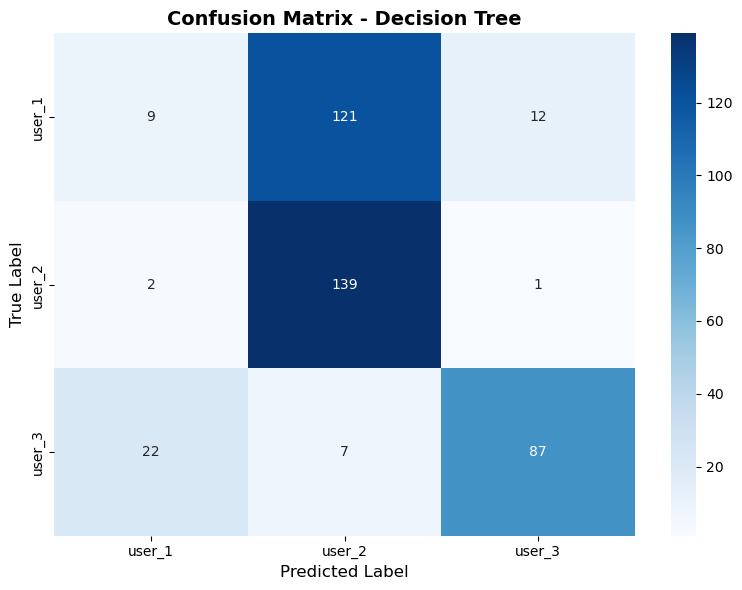


TRAINING: Logistic Regression

Validation Accuracy: 0.8625

Classification Report:
              precision    recall  f1-score   support

      user_1       0.87      0.80      0.83       142
      user_2       0.84      0.92      0.88       142
      user_3       0.89      0.87      0.88       116

    accuracy                           0.86       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.86      0.86      0.86       400



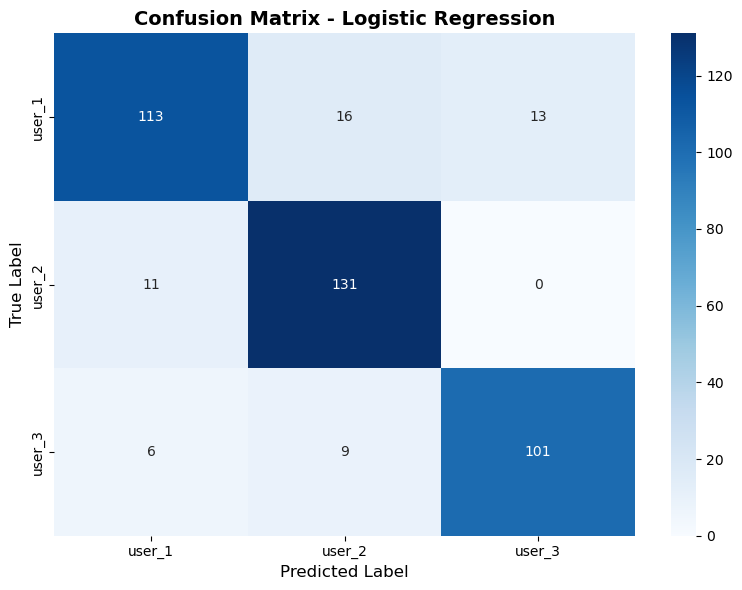


TRAINING: Random Forest

Validation Accuracy: 0.9075

Classification Report:
              precision    recall  f1-score   support

      user_1       0.88      0.89      0.88       142
      user_2       0.97      0.89      0.93       142
      user_3       0.88      0.96      0.92       116

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.91       400
weighted avg       0.91      0.91      0.91       400



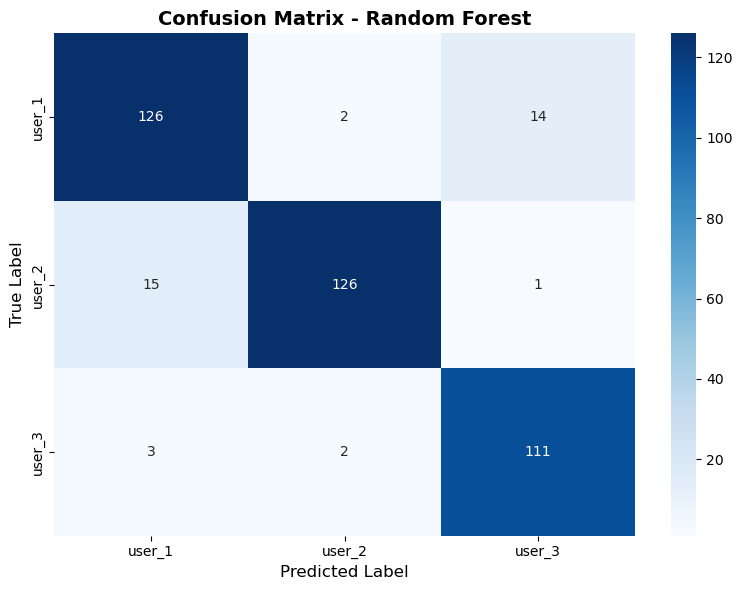

In [34]:
# Initialize classifiers
classifiers = {
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=15),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=2000, solver='saga'),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=15)
}

results = {}
unique_labels = sorted(y_train.unique())

for name, clf in classifiers.items():
    print(f"\n{'='*60}")
    print(f"TRAINING: {name}")
    print(f"{'='*60}")
    
    # Train
    clf.fit(X_train_scaled, y_train)
    
    # Predict on validation set
    y_pred = clf.predict(X_val_scaled)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_val, y_pred)
    results[name] = accuracy
    
    print(f"\nValidation Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=unique_labels,
                yticklabels=unique_labels)
    plt.title(f'Confusion Matrix - {name}', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()

### 2.2 Model Comparison


MODEL COMPARISON
Decision Tree: 0.5875
Logistic Regression: 0.8625
Random Forest: 0.9075


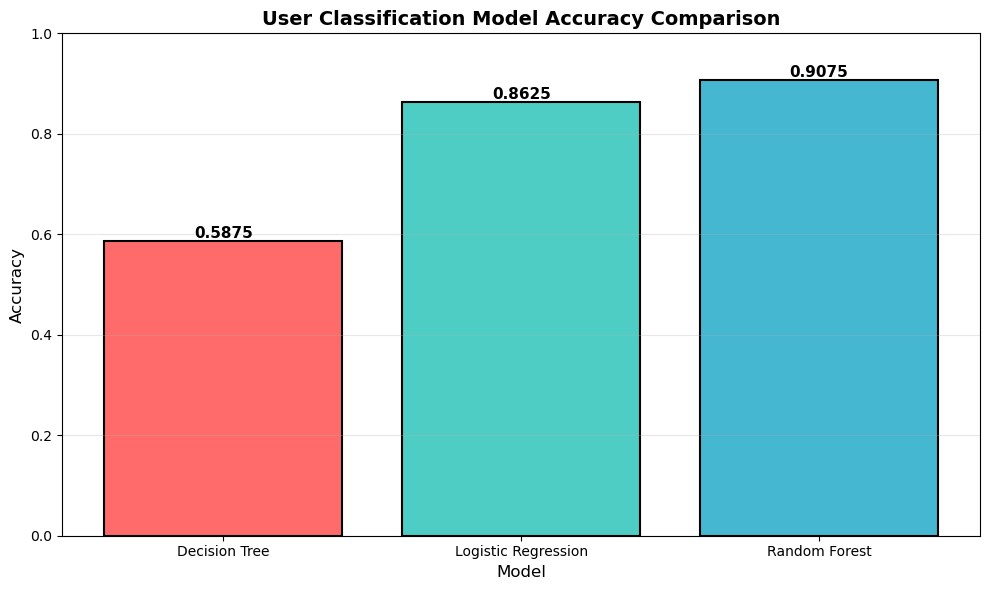


🏆 Best Model: Random Forest
   Validation Accuracy: 0.9075


In [35]:
# Compare models
print(f"\n{'='*60}")
print("MODEL COMPARISON")
print(f"{'='*60}")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

# Visualize
plt.figure(figsize=(10, 6))
models = list(results.keys())
accuracies = list(results.values())
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars = plt.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)
plt.title('User Classification Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim([0, 1.0])
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

best_model_name = max(results, key=results.get)
best_model = classifiers[best_model_name]
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Validation Accuracy: {results[best_model_name]:.4f}")

### 2.3 Save the Best Model (Optional)

In [36]:
import pickle

# Save the best model and preprocessing objects
with open('user_classifier.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

print("\nModel and preprocessing objects saved successfully!")


Model and preprocessing objects saved successfully!


## Summary

### Data Preprocessing
- Loaded training and test user datasets
- Handled missing values using median (numerical) and mode (categorical)
- Encoded categorical features using LabelEncoder
- Scaled features using StandardScaler

### User Classification
- Trained three different classifiers: Decision Tree, Logistic Regression, and Random Forest
- Evaluated models on test dataset
- Selected the best performing model based on accuracy

### Results

- Best Model: [Random Forest]
- Test Accuracy: [0.9075]

This classifier will serve as the **Context Detector** for the contextual bandit system in the next phase of the assignment.